<a href="https://colab.research.google.com/github/mehedihasan-cse/GDELT-Project/blob/main/GDELT_Code_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Cleanup and Re-execution
This section contains the consolidated and cleaned analysis pipeline, focusing exclusively on InflaBERT sentiment and ONS econometric validation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import torch
import requests
import time
import statsmodels.api as sm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertTokenizer
from io import StringIO
from sklearn.metrics import mean_squared_error, r2_score
import torch.nn.functional as F

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Global device: {device}")

Global device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/GDELT/GDELT_Data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12334 entries, 0 to 12333
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GKGRECORDID                11227 non-null  object 
 1   DATE                       12334 non-null  float64
 2   ArticleDate                11227 non-null  object 
 3   Month                      12334 non-null  object 
 4   SourceCommonName           12334 non-null  object 
 5   Host                       11227 non-null  object 
 6   RegisteredDomain           11227 non-null  object 
 7   Headline                   12334 non-null  object 
 8   GDELT_AvgTone              12334 non-null  float64
 9   GDELT_PositiveScore        12334 non-null  float64
 10  GDELT_NegativeScore        12334 non-null  float64
 11  GDELT_Polarity             12334 non-null  float64
 12  V2Tone                     12334 non-null  object 
 13  V2Themes                   12297 non-null  obj

In [ ]:
print(df['SourceCommonName'].value_counts())


SourceCommonName
dailymail.co.uk                  4087
theguardian.com                  2385
mirror.co.uk                     2007
independent.co.uk                1275
sky.com                           794
bbc.co.uk                         758
telegraph.co.uk                   436
thetimes.co.uk                    298
lancashiretelegraph.co.uk          73
thesun.co.uk                       52
greenocktelegraph.co.uk            29
westerntelegraph.co.uk             24
hulldailymail.co.uk                22
eastmoney.com                      22
enfieldindependent.co.uk           17
thetottenhamindependent.co.uk      14
insidermonkey.com                  13
grimsbytelegraph.co.uk             11
ey.com                              5
derbytelegraph.co.uk                4
infomoney.com.br                    4
niesr.ac.uk                         1
skynews.com.au                      1
fortuneturkey.com                   1
insideottawavalley.com              1
Name: count, dtype: int64


In [ ]:
non_uk_domains = [
    'eastmoney.com',
    'insidermonkey.com',
    'ey.com',
    'infomoney.com.br',
    'skynews.com.au',
    'fortuneturkey.com',
    'insideottawavalley.com'
]

non_uk_articles = df[df['SourceCommonName'].isin(non_uk_domains)]

print(f"Found {len(non_uk_articles)} articles from non-UK specific news domains.")
display(non_uk_articles[['SourceCommonName', 'Headline', 'ArticleDate']].head())

Found 47 articles from non-UK specific news domains.


,SourceCommonName,Headline,ArticleDate
1786,ey.com,"Despite Economic Uncertainty, 95% of Entrepren...",2025-06-03
2461,ey.com,EY survey reveals upcoming US presidential ele...,2024-10-18
4846,ey.com,Global economic outlook: growth strategies in ...,2024-07-25
8067,ey.com,US M&A momentum accelerates: EY-Parthenon fore...,2025-10-28
8567,ey.com,EY Entrepreneur Ecosystem Barometer: entrepren...,2024-11-12


In [ ]:
initial_rows = len(df)
df = df[~df['SourceCommonName'].isin(non_uk_domains)].copy()
print(f"Dropped {initial_rows - len(df)} rows from non-UK specific domains.")
print(f"Remaining rows in DataFrame: {len(df)}")

Dropped 47 rows from non-UK specific domains.
Remaining rows in DataFrame: 12287


In [ ]:
print(df['SourceCommonName'].value_counts())

SourceCommonName
dailymail.co.uk                  4087
theguardian.com                  2385
mirror.co.uk                     2007
independent.co.uk                1275
sky.com                           794
bbc.co.uk                         758
telegraph.co.uk                   436
thetimes.co.uk                    298
lancashiretelegraph.co.uk          73
thesun.co.uk                       52
greenocktelegraph.co.uk            29
westerntelegraph.co.uk             24
hulldailymail.co.uk                22
enfieldindependent.co.uk           17
thetottenhamindependent.co.uk      14
grimsbytelegraph.co.uk             11
derbytelegraph.co.uk                4
niesr.ac.uk                         1
Name: count, dtype: int64


In [ ]:
columns_to_drop = [
    'DATE', 'GKGRECORDID', 'Host', 'RegisteredDomain',
    'SourceGroup', 'UK_Strict_Flag', 'Core_Inflation_Flag',
    'UK_Relevance_Flag', 'Inflation_Relevance_Flag',
    'Expectation_Language_Flag', 'Amounts', 'GCAM',
    'Dates', 'ArticleDateTime', 'Quotations'
]
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore').copy()

# Standardize Dates and filter nulls - added explicit format to fix UserWarning
df['Month_Date'] = pd.to_datetime(df['Month'], format='%Y-%m')
df['ArticleDate'] = pd.to_datetime(df['ArticleDate']).fillna(df['Month_Date'])
df['Month_Key'] = df['Month_Date'].dt.strftime('%Y-%m')

df.dropna(subset=['Extracted_Text', 'V2Themes'], inplace=True)
df['Extracted_Text'] = df['Extracted_Text'].apply(lambda x: re.sub(r'<.*?>', '', str(x)))

print(f'Data loaded: {len(df)} records available for analysis.')

Data loaded: 11929 records available for analysis.


In [ ]:
df.tail(5)

,ArticleDate,Month,SourceCommonName,Headline,GDELT_AvgTone,GDELT_PositiveScore,GDELT_NegativeScore,GDELT_Polarity,V2Tone,V2Themes,V2Locations,V2Persons,V2Organizations,DocumentIdentifier,Extracted_Text,Word_Count,Month_Date,Month_Key
12300,2026-04-01,2026-04,dailymail.co.uk,POLL OF THE DAY: Did Starmer always intend to ...,-2.000000,2.000000,4.000000,6.000000,"-2,2,4,6,27,1.5,192","WB_2433_CONFLICT_AND_VIOLENCE,674;WB_2432_FRAG...",NaN,"Sadiq Khan,994;Keir Starmer,12;Priti Patel,447","European Union,90",https://www.dailymail.co.uk/news/article-15704...,Keir Starmer said on Wednesday he will pursue ...,194,2026-04-01,2026-04
12301,2026-05-01,2026-05,bbc.co.uk,The Global Story - Why Britain keeps losing pr...,-1.058201,3.703704,4.761905,8.465608,"-1.05820105820106,3.7037037037037,4.7619047619...","TAX_FNCACT_EXECUTIVE,895;TAX_FNCACT_CORRESPOND...",NaN,"James Landale,825;Hannah Moore,871;Keir Starme...","European Union,86",https://www.bbc.co.uk/sounds/play/w3ct8mks,Available for over a year\n\nIn the decade sin...,185,2026-05-01,2026-05
12302,2026-05-01,2026-05,bbc.co.uk,UK growth forecast upgraded by IMF but 'risks'...,-4.225352,1.760563,5.985915,7.746479,"-4.22535211267606,1.76056338028169,5.985915492...","WB_1944_INNOVATION_AND_PRODUCTIVITY_GROWTH,172...",NaN,"Rachel Reeves,676;Luc Eyraud,1332;Keir Starmer...",NaN,https://www.bbc.co.uk/news/articles/cm2p72mmddyo,The International Monetary Fund (IMF) has upgr...,182,2026-05-01,2026-05
12303,2026-04-01,2026-04,theguardian.com,What will the UK's role be in the strait of Ho...,-3.576341,2.200825,5.777166,7.977992,"-3.57634112792297,2.20082530949106,5.777166437...","TAX_ECON_PRICE,338;GENERAL_GOVERNMENT,4154;EPU...",NaN,"John Healey,3751;Keir Starmer,209","Threat Exploitation Group,1177;Royal Navy,743;...",https://www.theguardian.com/world/2026/apr/13/...,The UK will co-host an international summit of...,153,2026-04-01,2026-04
12304,2026-06-01,2026-06,bbc.co.uk,Inflation unexpectedly steady as food price ri...,0.000000,0.000000,0.000000,0.000000,"0,0,0,0,21.505376344086,0,173","AGRICULTURE,942;TAX_FNCACT_FARMERS,942;TAX_FNC...",NaN,"Karen Betts,856","British Retail Consortium,523",https://www.bbc.co.uk/news/articles/cyv0qpn9zvjo,Inflation remained at 2.8% in the year to May ...,141,2026-06-01,2026-06



**Acess Issue text Remove.**



In [ ]:
specific_access_issue_text = """Access Issue Help\n\nYou are seeing this page because our security systems have detected some unusual activity on this connection. To regain access to The Telegraph website please try the following:\n\nIf you are connected to the internet using a VPN client we recommend disconnecting/disabling it.\n\nVisit The Telegraph website using a different web browser (e.g. Chrome, Safari, or Firefox).\n\nVisit The Telegraph website from your mobile device or from a different PC.\n\nIf you’re still having trouble, please contact our Customer Support Team using the following link and quoting the Akamai Reference Number (ak_ref_id) below."""

# Count occurrences of the specific access issue text
count_specific_access_issue = df['Extracted_Text'].str.contains(specific_access_issue_text, case=False, na=False, regex=False).sum()

print(f"Number of articles with the specific 'Access Issue Help' text: {count_specific_access_issue}")

# Remove articles containing this specific text
initial_rows_before_removal = len(df)
filter_out_access_issues = ~df['Extracted_Text'].str.contains(specific_access_issue_text, case=False, na=False, regex=False)
df = df[filter_out_access_issues].copy()

rows_removed = initial_rows_before_removal - len(df)
print(f"Removed {rows_removed} articles containing the specific 'Access Issue Help' text.")
print(f"Remaining rows in DataFrame: {len(df)}")

Number of articles with the specific 'Access Issue Help' text: 304
Removed 304 articles containing the specific 'Access Issue Help' text.
Remaining rows in DataFrame: 11625


In [ ]:
initial_rows = len(df)
# Ensure 'ArticleDate' is in datetime format
df['ArticleDate'] = pd.to_datetime(df['ArticleDate'])

# Define the cutoff date
cutoff_date = pd.to_datetime('2024-01-01')

# Filter the DataFrame to keep only articles from the cutoff date onwards
df = df[df['ArticleDate'] >= cutoff_date].copy()

rows_dropped = initial_rows - len(df)
print(f"Dropped {rows_dropped} articles published before {cutoff_date.strftime('%Y-%m-%d')}.")
print(f"Remaining rows in DataFrame: {len(df)}")

Dropped 1527 articles published before 2024-01-01.
Remaining rows in DataFrame: 10098


Max ArticleDate after cleaning (used previously for plot): 2026-06-01 00:00:00
Max Month in data (now used for plot): 2026-06


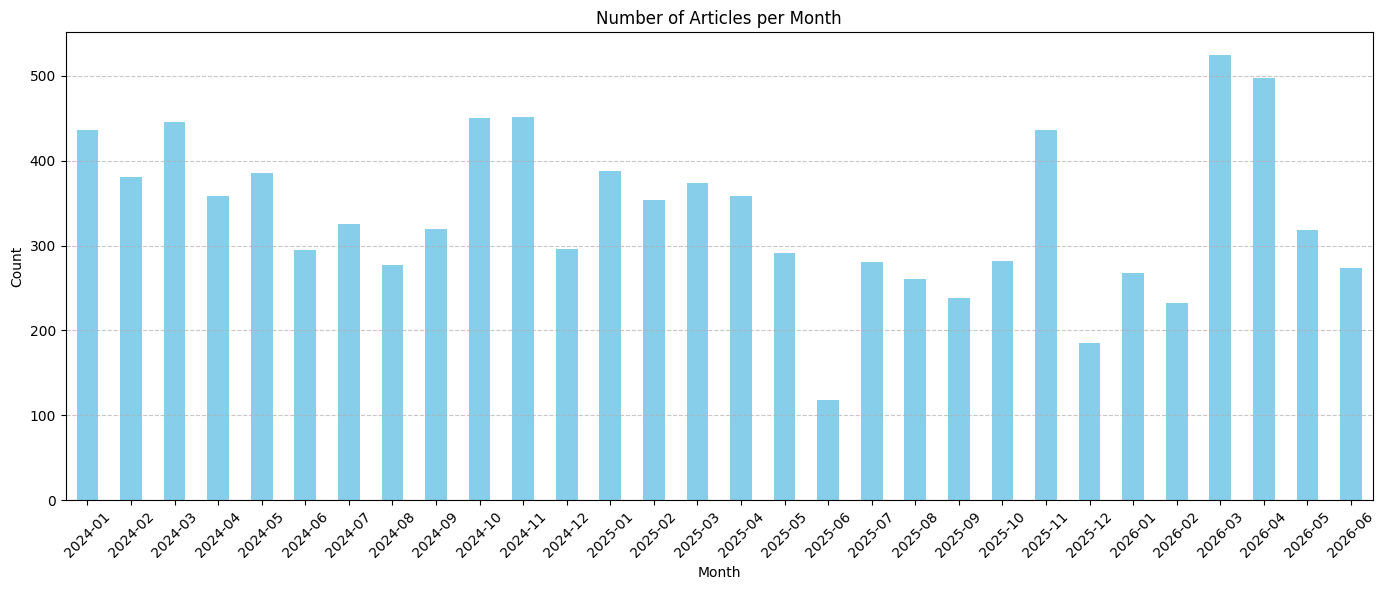

We have 30 months of data.

Last few months in the monthly counts:
Month
2026-02    232
2026-03    525
2026-04    498
2026-05    318
2026-06    274
Freq: M, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure ArticleDate is datetime
df['ArticleDate'] = pd.to_datetime(df['ArticleDate'])

# Print max of ArticleDate after cleaning to confirm what's available
print(f"Max ArticleDate after cleaning (used previously for plot): {df['ArticleDate'].max()}")
# Print max of Month column to see the full range
print(f"Max Month in data (now used for plot): {pd.to_datetime(df['Month']).dt.to_period('M').max()}")

# Group by month and count records, using the 'Month' column for completeness
# Convert 'Month' column to datetime objects first, then to period for consistent grouping
monthly_counts = df.groupby(pd.to_datetime(df['Month']).dt.to_period('M')).size()

# Plotting
plt.figure(figsize=(14, 6))
monthly_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Articles per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

num_months = len(monthly_counts)
print(f"We have {num_months} months of data.")

# Additionally, print the last few months of the monthly_counts to check the end of the series
print("\nLast few months in the monthly counts:")
print(monthly_counts.tail())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10098 entries, 0 to 12304
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ArticleDate          10098 non-null  datetime64[ns]
 1   Month                10098 non-null  object        
 2   SourceCommonName     10098 non-null  object        
 3   Headline             10098 non-null  object        
 4   GDELT_AvgTone        10098 non-null  float64       
 5   GDELT_PositiveScore  10098 non-null  float64       
 6   GDELT_NegativeScore  10098 non-null  float64       
 7   GDELT_Polarity       10098 non-null  float64       
 8   V2Tone               10098 non-null  object        
 9   V2Themes             10098 non-null  object        
 10  V2Locations          8835 non-null   object        
 11  V2Persons            9173 non-null   object        
 12  V2Organizations      8426 non-null   object        
 13  DocumentIdentifier   10098 non-null 

In [ ]:
df.isnull().sum()

,0
ArticleDate,0
Month,0
SourceCommonName,0
Headline,0
GDELT_AvgTone,0
GDELT_PositiveScore,0
GDELT_NegativeScore,0
GDELT_Polarity,0
V2Tone,0
V2Themes,0


In [ ]:
# Clean missing values for core analysis columns immediately
initial_count = len(df)
df.dropna(subset=['Extracted_Text', 'V2Themes'], inplace=True)

print(f"Rows before cleaning: {initial_count}")
print(f"Rows after removing null text/themes: {len(df)}")
print(f"Data now contains {df['ArticleDate'].nunique()} unique dates across {df['Month'].nunique()} months.")

Rows before cleaning: 10098
Rows after removing null text/themes: 10098
Data now contains 805 unique dates across 30 months.


In [ ]:
df.isnull().sum()

,0
ArticleDate,0
Month,0
SourceCommonName,0
Headline,0
GDELT_AvgTone,0
GDELT_PositiveScore,0
GDELT_NegativeScore,0
GDELT_Polarity,0
V2Tone,0
V2Themes,0


In [ ]:
highest_word_count_article = df.loc[df['Word_Count'].idxmax()]
print(f"Word Count: {highest_word_count_article['Word_Count']}")
print("Full Extracted Text:")
print(highest_word_count_article['Extracted_Text'])

Word Count: 8453
Full Extracted Text:
Watch the trailer for Civilisations: Rise and Fall

The moments when four ancient worlds faced disaster are brought to life in an epic new series exploring Rome, Egypt, the Aztecs and the samurai of Japan. Drawing on the beautiful art and artefacts left behind by these four cultures, now held in the British Museum, the series reveals the human stories at the heart of each crisis. A BBC Studios production for BBC Two and iPlayer, Civilisations: Rise and Fall begins on 24 November



CB Introduction from Suzy Klein, Head of BBC Arts & Classical Music TV “Bringing Civilisations back is a momentous occasion, and a real honour. Civilisation - as it was originally known - first aired in 1969, hosted by Kenneth Clark. This series became a defining piece of television, opening up a world of art and culture to audiences at home - and spectacularly in colour. “In 2018, Dame Mary Beard, David Olusoga, and Simon Schama took the helm and expanded the series’ sc

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

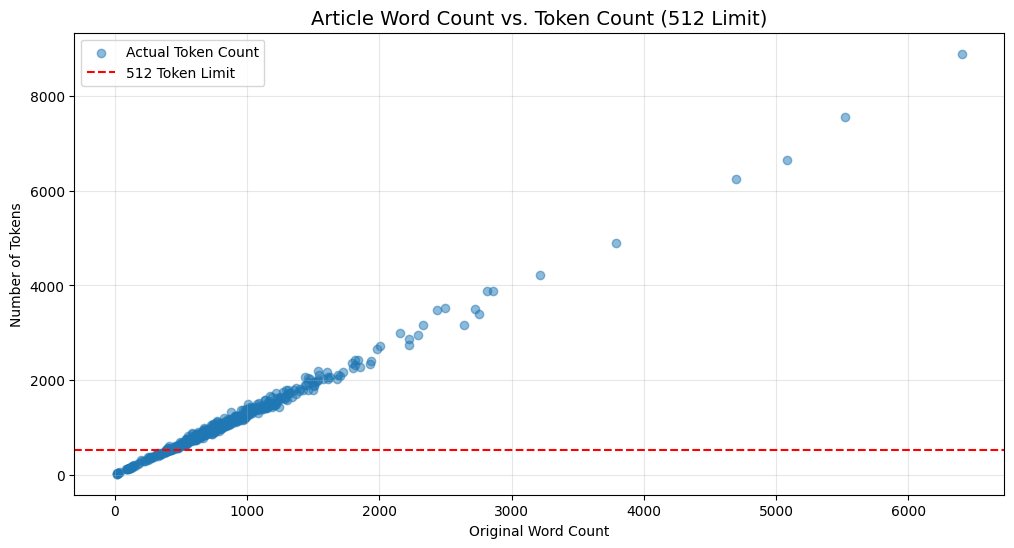

On average, 512 tokens covers approximately 2392 characters.
Articles above the red line are currently being truncated (cut off).


In [ ]:
import matplotlib.pyplot as plt
from transformers import BertTokenizer, AutoTokenizer # Ensure BertTokenizer is imported

# Define fin_tokenizer here to ensure it's available
fin_model_name = 'yiyanghkust/finbert-tone'
fin_tokenizer = BertTokenizer.from_pretrained(fin_model_name)

# We will use the FinBERT tokenizer as a proxy for the 512 token limit
def get_token_cutoff_info(text, limit=512):
    if not isinstance(text, str): return 0, 0
    tokens = fin_tokenizer.tokenize(text)
    # Get the text represented by only the first 512 tokens
    truncated_text = fin_tokenizer.convert_tokens_to_string(tokens[:limit])
    return len(truncated_text), len(tokens)

# Sample a subset to save time if the DF is large
sample_df = df.sample(min(500, len(df))).copy()
cutoff_data = sample_df['Extracted_Text'].apply(get_token_cutoff_info)
sample_df['Char_Length_at_512'], sample_df['Total_Tokens'] = zip(*cutoff_data)

# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(sample_df['Word_Count'], sample_df['Total_Tokens'], alpha=0.5, label='Actual Token Count')
plt.axhline(y=512, color='r', linestyle='--', label='512 Token Limit')

plt.title('Article Word Count vs. Token Count (512 Limit)', fontsize=14)
plt.xlabel('Original Word Count')
plt.ylabel('Number of Tokens')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary stats
avg_chars = sample_df[sample_df['Total_Tokens'] > 512]['Char_Length_at_512'].mean()
print(f"On average, 512 tokens covers approximately {avg_chars:.0f} characters.")
print(f"Articles above the red line are currently being truncated (cut off).")

### Text Preprocessing
Defining functions to clean HTML tags, remove punctuation, and lemmatize text for analysis.

In [ ]:
def remove_html_tags(text):
    """Removes HTML tags from a string using regex."""
    if not isinstance(text, str): return ""
    return re.sub(r'<.*?>', '', text)

# def preprocess_text(text):
#     """Cleans text: lowercases, removes punctuation/stopwords, and lemmatizes."""
#     if not isinstance(text, str): return ''
#     stop_words = set(stopwords.words('english'))
#     lemmatizer = WordNetLemmatizer()


    # text = text.lower().translate(str.maketrans('', '', string.punctuation))
    # words = text.split()
    # cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    # return ' '.join(cleaned_words)

In [ ]:
# Apply the cleaning pipeline defined in the previous cell
df['Extracted_Text'] = df['Extracted_Text'].apply(remove_html_tags)#.apply(preprocess_text)
display(df[['Extracted_Text']].head())

,Extracted_Text
0,"The government is spending £22bn on ""unproven""..."
1,Donald Trump has raised hopes several times th...
2,The price of oil has risen sharply on the back...
3,The International Monetary Fund (IMF) has upgr...
4,"What's abnormal about today's announcement, ac..."


In [ ]:
# Consolidated Model Loading
inf_model_name = 'MAPAi/InflaBERT'
inf_tokenizer = AutoTokenizer.from_pretrained(inf_model_name)
inf_model = AutoModelForSequenceClassification.from_pretrained(inf_model_name).to(device).eval()

def get_softmax_sentiment(text, max_length=512, stride=256):
    """Processes full text using sliding window and returns Softmax-based probabilities/polarity."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0, 1.0, 0.0, 0.0

    tokens = inf_tokenizer(text, return_tensors='pt', truncation=False).to(device)
    input_ids = tokens['input_ids'][0]

    def process_window(ids):
        with torch.no_grad():
            logits = inf_model(ids.unsqueeze(0)).logits
            probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
        return probs

    if len(input_ids) <= max_length:
        probs = process_window(input_ids)
    else:
        window_probs = []
        for i in range(0, len(input_ids), stride):
            window = input_ids[i : i + max_length]
            if len(window) < 32: break
            window_probs.append(process_window(window))
        probs = np.mean(window_probs, axis=0) if window_probs else np.array([0.0, 1.0, 0.0])

    # 0: Down, 1: Neutral, 2: Up
    p_down, p_neutral, p_up = probs[0], probs[1], probs[2]
    return p_down, p_neutral, p_up, (p_up - p_down)

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.41k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  328MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [ ]:
import time
import numpy as np

# Recalculate Month_Key to ensure all rows are groupable
df['Month_Key'] = pd.to_datetime(df['Month']).dt.strftime('%Y-%m')

# Ensure baseline exists
if 'GDELT_Normalized' not in df.columns:
    mu, sigma = df['GDELT_AvgTone'].mean(), df['GDELT_AvgTone'].std()
    df['GDELT_Normalized'] = np.clip((df['GDELT_AvgTone'] - mu) / (2 * sigma), -1, 1)

print(f"Processing Full-Text InflaBERT sentiment for all {len(df)} articles using sliding window...")
start_time = time.time()

# Apply updated sliding-window sentiment analysis
# Use get_softmax_sentiment and unpack all returned values, then select the polarity
results = df['Extracted_Text'].apply(lambda x: get_softmax_sentiment(x))
df['P_DOWN'], df['P_NEUTRAL'], df['P_UP'], df['InflaBERT_Polarity'] = zip(*results) # Correctly unpack

# Update the monthly sentiment aggregation
monthly_sentiment = df.groupby('Month_Key').agg({
    'InflaBERT_Polarity': 'mean', # Use InflaBERT_Polarity
    'GDELT_Normalized': 'mean'
}).reset_index()

end_time = time.time()
print(f"Finished! Full-text analysis complete through {df['Month_Key'].max()}.")
print(f"Total time: {(end_time - start_time) / 60:.2f} minutes.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (626 > 512). Running this sequence through the model will result in indexing errors


Processing Full-Text InflaBERT sentiment for all 10098 articles using sliding window...
Finished! Full-text analysis complete through 2026-06.
Total time: 12.74 minutes.


In [ ]:
# Display the aggregated sentiment scores for all months using the new Softmax Polarity
# The Polarity score (P_UP - P_DOWN) is mathematically bound between -1 and +1.
print("--- Monthly Average InflaBERT Softmax Polarity ---")
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4f}'.format):
    # Updating reference from 'InflaBERT_Combined' to 'InflaBERT_Polarity'
    display(monthly_sentiment[['Month_Key', 'InflaBERT_Polarity']])

--- Monthly Average InflaBERT Softmax Polarity ---


,Month_Key,InflaBERT_Polarity
0,2024-01,0.1277
1,2024-02,0.0661
2,2024-03,0.0051
3,2024-04,0.0533
4,2024-05,-0.0637
5,2024-06,-0.0076
6,2024-07,0.0531
7,2024-08,0.1424
8,2024-09,0.0246
9,2024-10,0.0951


### Sentiment Analysis
Calculating average sentiment scores for articles by processing text in chunks.

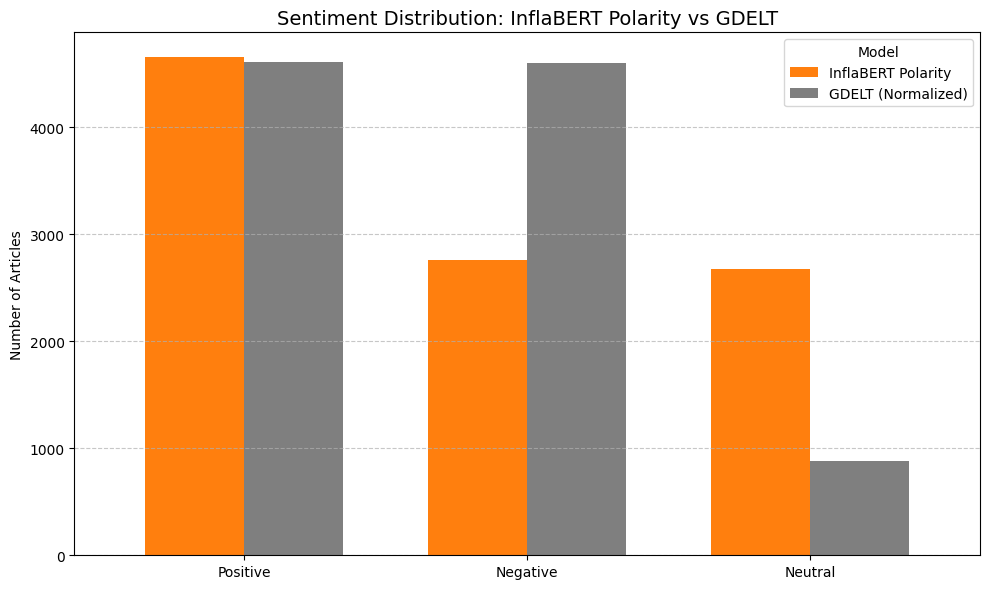

,InflaBERT Polarity,GDELT (Normalized)
Positive,4656,4611
Negative,2763,4602
Neutral,2679,885


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def extract_v2tone(tone_str):
    try:
        return float(tone_str.split(',')[0]) / 10.0
    except:
        return 0.0

df['GDELT_V2Tone_Score'] = df['V2Tone'].apply(extract_v2tone)
raw_gdelt = df['GDELT_V2Tone_Score'].values
mu, sigma = np.mean(raw_gdelt), np.std(raw_gdelt)
df['GDELT_Normalized'] = np.clip((df['GDELT_V2Tone_Score'] - mu) / (2 * sigma), -1, 1)

def categorize_score(score):
    if score > 0.05: return 'Positive'
    if score < -0.05: return 'Negative'
    return 'Neutral'

df['InflaBERT_Label'] = df['InflaBERT_Polarity'].apply(categorize_score)
df['GDELT_Label'] = df['GDELT_Normalized'].apply(categorize_score)

inf_dist = df['InflaBERT_Label'].value_counts().rename('InflaBERT Polarity')
gd_dist = df['GDELT_Label'].value_counts().rename('GDELT (Normalized)')
dist_df = pd.concat([inf_dist, gd_dist], axis=1).fillna(0)

ax = dist_df.plot(kind='bar', figsize=(10, 6), color=['#ff7f0e', '#7f7f7f'], width=0.7)
plt.title('Sentiment Distribution: InflaBERT Polarity vs GDELT', fontsize=14)
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
display(dist_df)

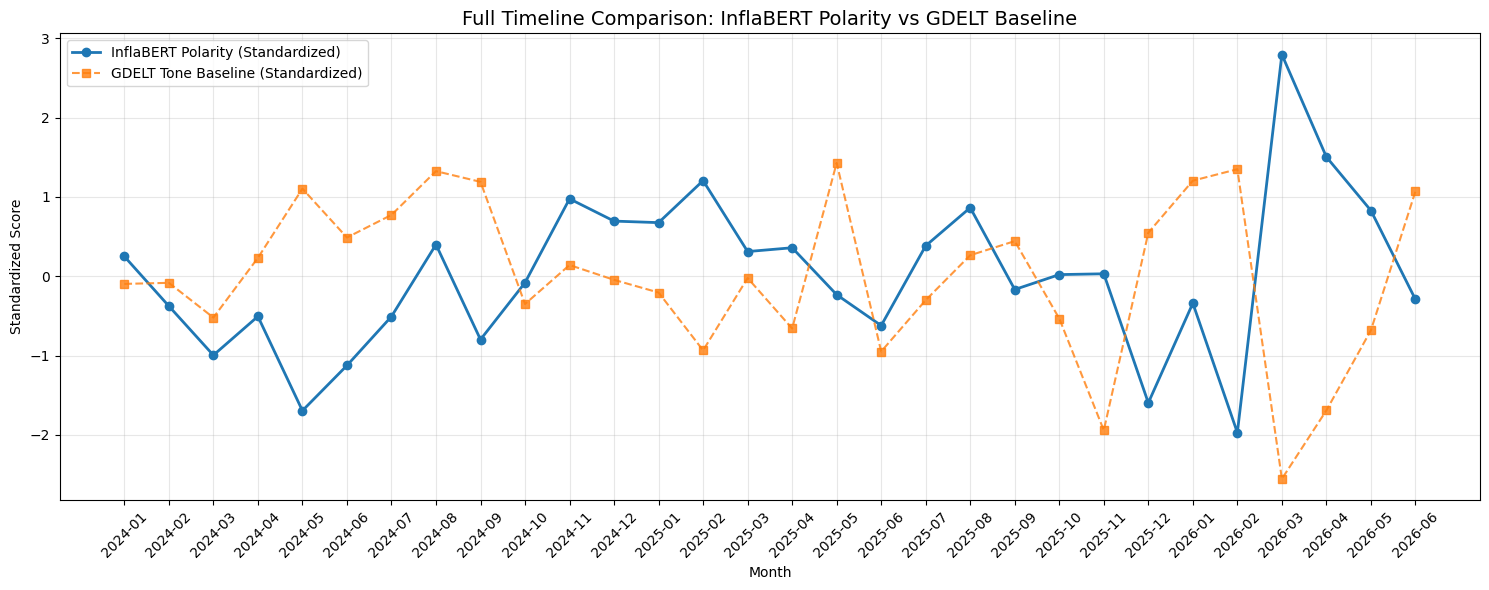

Correlation between InflaBERT Polarity and GDELT: -0.6376


In [ ]:
def extract_v2tone(tone_str):
    try:
        return float(tone_str.split(',')[0])
    except:
        return 0.0

df['GDELT_Tone'] = df['V2Tone'].apply(extract_v2tone)

def normalize(series):
    return (series - series.mean()) / series.std()

# Updated to use InflaBERT_Polarity instead of Combined
monthly_comp = df.groupby('Month_Key').agg({
    'InflaBERT_Polarity': 'mean',
    'GDELT_Tone': 'mean'
}).reset_index()

monthly_comp['InflaBERT_Z'] = normalize(monthly_comp['InflaBERT_Polarity'])
monthly_comp['GDELT_Z'] = normalize(monthly_comp['GDELT_Tone'])

plt.figure(figsize=(15, 6))
plt.plot(monthly_comp['Month_Key'], monthly_comp['InflaBERT_Z'], label='InflaBERT Polarity (Standardized)', marker='o', linewidth=2)
plt.plot(monthly_comp['Month_Key'], monthly_comp['GDELT_Z'], label='GDELT Tone Baseline (Standardized)', marker='s', linestyle='--', alpha=0.8)

plt.title('Full Timeline Comparison: InflaBERT Polarity vs GDELT Baseline', fontsize=14)
plt.ylabel('Standardized Score')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation between InflaBERT Polarity and GDELT: {monthly_comp['InflaBERT_Polarity'].corr(monthly_comp['GDELT_Tone']):.4f}")

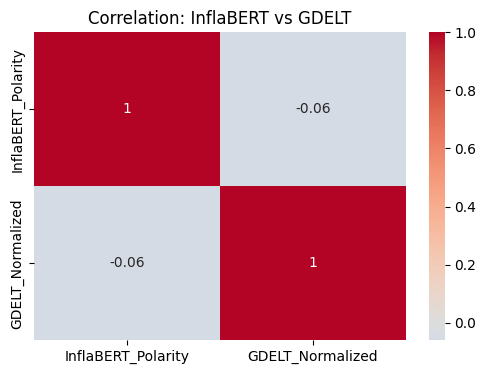

,InflaBERT_Polarity,GDELT_Normalized
InflaBERT_Polarity,1.000000,-0.059785
GDELT_Normalized,-0.059785,1.000000


In [ ]:
# Correlation Heatmap: InflaBERT vs GDELT
model_corr = df[['InflaBERT_Polarity', 'GDELT_Normalized']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(model_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: InflaBERT vs GDELT')
plt.show()

display(model_corr)

### Live Data Retrieval from ONS
Instead of a static CSV, we can pull the 'Consumer Price Inflation time series' (MM23) directly from the ONS. Series **D7BT** corresponds to the CPI Index (2015=100).

In [ ]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

def get_live_uk_cpi():
    # ONS URL for the CPI All Items Index (Series ID: D7BT)
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23"

    try:
        response = requests.get(url)
        response.raise_for_status()
        data = StringIO(response.text)

        # ONS CSVs have metadata in the first few rows
        live_df = pd.read_csv(data, skiprows=8, names=['Date', 'CPI_Index'])

        # Filter for monthly data
        live_df = live_df[live_df['Date'].str.contains(r'\d{4} [A-Z]{3}', na=False)].copy()
        live_df['Date'] = pd.to_datetime(live_df['Date'], format='%Y %b')
        live_df['CPI_Index'] = pd.to_numeric(live_df['CPI_Index'])

        # Updated filter for 2023-2026 to match the full GDELT timeline
        live_df = live_df[(live_df['Date'].dt.year >= 2023) & (live_df['Date'].dt.year <= 2026)]
        live_df = live_df.sort_values('Date')

        # Calculate Inflation Rate (Log Difference)
        live_df['Log_CPI'] = np.log(live_df['CPI_Index'])
        live_df['Inflation_Rate_LogDiff'] = live_df['Log_CPI'].diff() * 100
        live_df['Month_Key'] = live_df['Date'].dt.strftime('%Y-%m')

        return live_df

    except Exception as e:
        print(f"Failed to fetch online data: {e}")
        return None

online_cpi = get_live_uk_cpi()
if online_cpi is not None:
    display(online_cpi.head())
    print(f"Online CPI data retrieved for timeline: {online_cpi['Month_Key'].min()} to {online_cpi['Month_Key'].max()}")

,Date,CPI_Index,Log_CPI,Inflation_Rate_LogDiff,Month_Key
612,2023-01-01,126.4,4.839451,NaN,2023-01
613,2023-02-01,127.9,4.851249,1.179723,2023-02
614,2023-03-01,128.9,4.859037,0.778820,2023-03
615,2023-04-01,130.4,4.870607,1.156974,2023-04
616,2023-05-01,131.3,4.877485,0.687813,2023-05


Online CPI data retrieved for timeline: 2023-01 to 2026-07


In [ ]:
# Fetch the data first to ensure online_cpi is defined in this session
online_cpi = get_live_uk_cpi()

if online_cpi is not None:
    # Ensure data is sorted by date for correct differencing
    online_cpi = online_cpi.sort_values('Date')

    # Calculate Log CPI levels
    online_cpi['Log_CPI'] = np.log(online_cpi['CPI_Index'])

    # Calculate First Log Difference (Inflation Rate)
    online_cpi['Inflation_Rate_LogDiff'] = online_cpi['Log_CPI'].diff() * 100

    print("--- Live CPI Transformation (Full Timeline) ---")
    # Set display options to show all rows for the full timeline
    with pd.option_context('display.max_rows', None):
        display(online_cpi[['Date', 'CPI_Index', 'Log_CPI', 'Inflation_Rate_LogDiff']])
else:
    print("Error: Could not retrieve live CPI data.")

--- Live CPI Transformation (Full Timeline) ---


,Date,CPI_Index,Log_CPI,Inflation_Rate_LogDiff
612,2023-01-01,126.4,4.839451,NaN
613,2023-02-01,127.9,4.851249,1.179723
614,2023-03-01,128.9,4.859037,0.778820
615,2023-04-01,130.4,4.870607,1.156974
616,2023-05-01,131.3,4.877485,0.687813
617,2023-06-01,131.5,4.879007,0.152207
618,2023-07-01,130.9,4.874434,-0.457318
619,2023-08-01,131.3,4.877485,0.305111
620,2023-09-01,132.0,4.882802,0.531714
621,2023-10-01,132.0,4.882802,0.000000


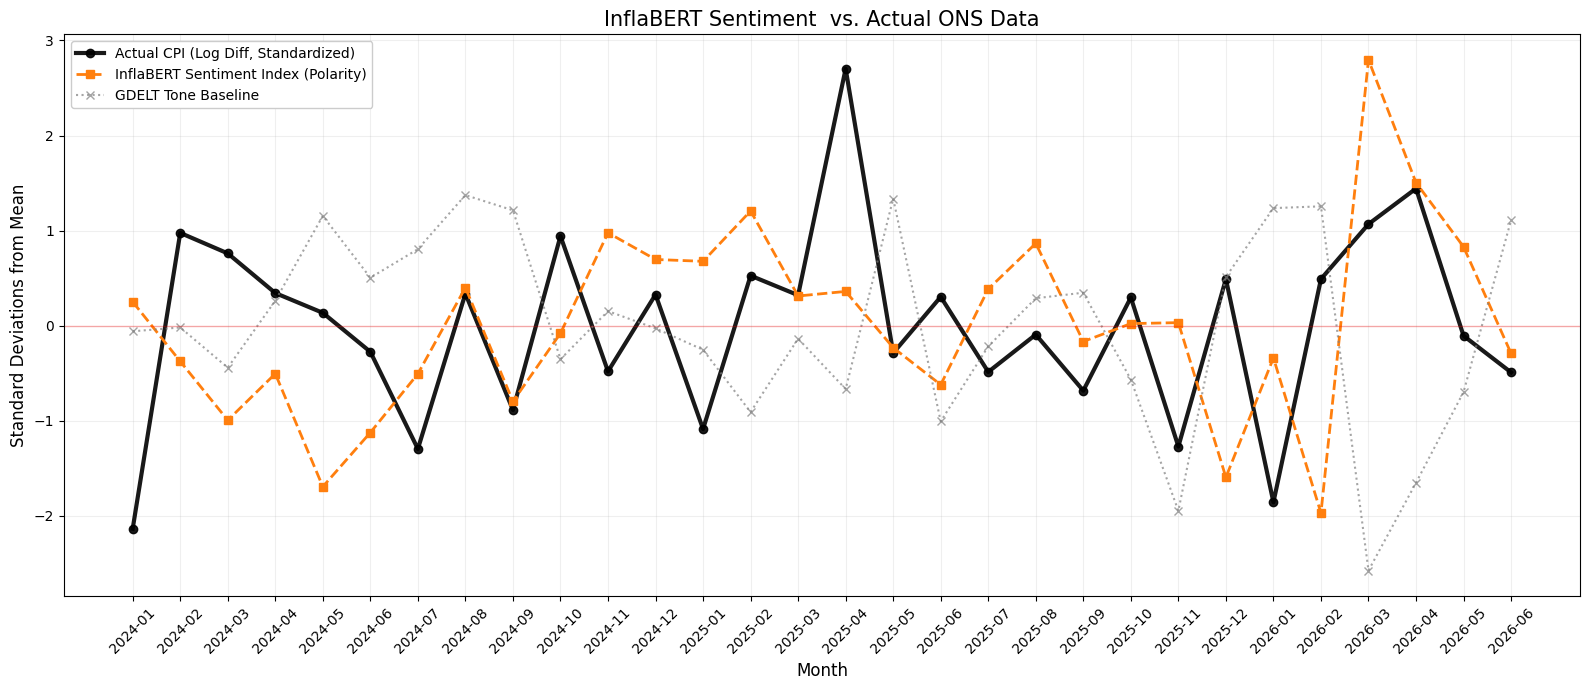

--- Correlation Matrix (Monthly Level) ---


,Inflation_Rate_LogDiff,InflaBERT_Polarity,GDELT_Normalized
Inflation_Rate_LogDiff,1.000000,0.144423,-0.338824
InflaBERT_Polarity,0.144423,1.000000,-0.634677
GDELT_Normalized,-0.338824,-0.634677,1.000000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df exists before grouping
if 'df' in globals():
    # 1. Ensure all series are aligned on Month_Key
    # Consistent with updated pipeline, we now use 'InflaBERT_Polarity'
    monthly_sentiment_agg = df.groupby('Month_Key').agg({
        'InflaBERT_Polarity': 'mean',
        'GDELT_Normalized': 'mean'
    }).reset_index()

    comparison_df = pd.merge(online_cpi, monthly_sentiment_agg, on='Month_Key', how='inner')

    # 2. Standardize all for visual overlay (Z-score normalization)
    def z_score(s):
        return (s - s.mean()) / s.std()

    comparison_df['CPI_Z'] = z_score(comparison_df['Inflation_Rate_LogDiff'])
    comparison_df['InflaBERT_Z'] = z_score(comparison_df['InflaBERT_Polarity'])
    comparison_df['GDELT_Z'] = z_score(comparison_df['GDELT_Normalized'])

    # 3. Plotting the Comparison
    plt.figure(figsize=(16, 7))

    plt.plot(comparison_df['Month_Key'], comparison_df['CPI_Z'], label='Actual CPI (Log Diff, Standardized)', color='black', linewidth=3, marker='o', alpha=0.9)
    plt.plot(comparison_df['Month_Key'], comparison_df['InflaBERT_Z'], label='InflaBERT Sentiment Index (Polarity)', color='#ff7f0e', linewidth=2, linestyle='--', marker='s')
    plt.plot(comparison_df['Month_Key'], comparison_df['GDELT_Z'], label='GDELT Tone Baseline', color='#7f7f7f', linewidth=1.5, linestyle=':', marker='x', alpha=0.7)

    plt.title('InflaBERT Sentiment  vs. Actual ONS Data', fontsize=15)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Standard Deviations from Mean', fontsize=12)
    plt.xticks(rotation=45)
    plt.axhline(0, color='red', linewidth=1, alpha=0.3)
    plt.grid(True, alpha=0.2)
    plt.legend(frameon=True, facecolor='white', framealpha=1)

    plt.tight_layout()
    plt.show()

    # Quick correlation table for context
    print("--- Correlation Matrix (Monthly Level) ---")
    display(comparison_df[['Inflation_Rate_LogDiff', 'InflaBERT_Polarity', 'GDELT_Normalized']].corr())
else:
    print("Error: 'df' is not defined. Please run the data loading cells first.")

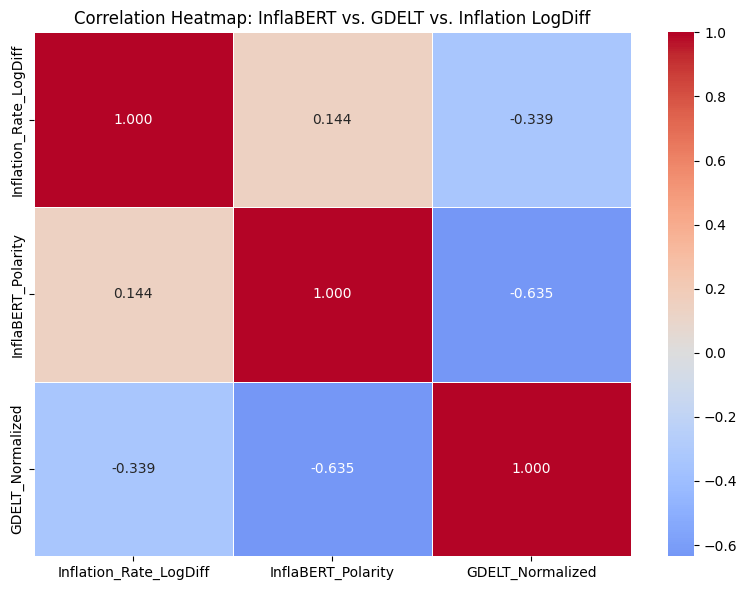

--- Correlation Matrix: InflaBERT vs GDELT vs Inflation ---


,Inflation_Rate_LogDiff,InflaBERT_Polarity,GDELT_Normalized
Inflation_Rate_LogDiff,1.000000,0.144423,-0.338824
InflaBERT_Polarity,0.144423,1.000000,-0.634677
GDELT_Normalized,-0.338824,-0.634677,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter the comparison_df to the relevant columns for this specific request
# 'Inflation_Rate_LogDiff' from ONS, 'InflaBERT_Polarity', and 'GDELT_Normalized'
core_corr_df = comparison_df[['Inflation_Rate_LogDiff', 'InflaBERT_Polarity', 'GDELT_Normalized']]

# Calculate correlation matrix
core_corr_matrix = core_corr_df.corr()

# Plot the heatmap separately
plt.figure(figsize=(8, 6))
sns.heatmap(core_corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=.5, center=0)
plt.title('Correlation Heatmap: InflaBERT vs. GDELT vs. Inflation LogDiff')
plt.tight_layout()
plt.show()

print("--- Correlation Matrix: InflaBERT vs GDELT vs Inflation ---")
display(core_corr_matrix)

/tmp/ipykernel_489/3874944152.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lag (Months)', y='Correlation', data=lag_df, palette='viridis')


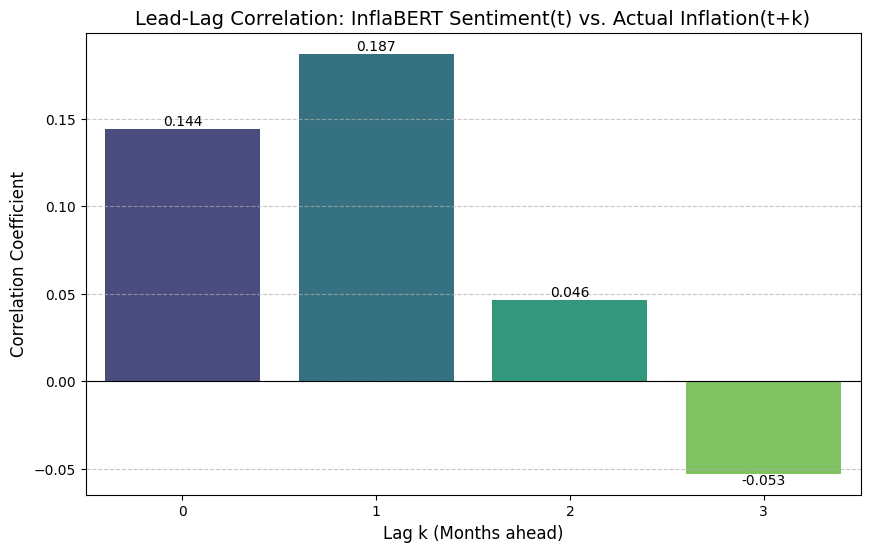

--- Cross-Correlation Summary ---
Lag 0: Current Month Inflation
Lag 1: Next Month Inflation (Lead signal)
Lag 2: Two Months Ahead Inflation
Lag 3: Three Months Ahead Inflation


,Lag (Months),Correlation
0,0,0.144423
1,1,0.187236
2,2,0.046459
3,3,-0.052965


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data using comparison_df (which has both CPI and Sentiment)
# We want to see how News(t) correlates with CPI(t+k)
lag_results = []

# We will test lags from 0 (contemporaneous) to 3 months ahead
for lag in range(4):
    # Shift CPI backward to align News(t) with CPI(t+lag)
    # Or shift News forward: News(t) vs CPI(t+lag)
    correlation = comparison_df['InflaBERT_Polarity'].corr(comparison_df['Inflation_Rate_LogDiff'].shift(-lag))
    lag_results.append({'Lag (Months)': lag, 'Correlation': correlation})

lag_df = pd.DataFrame(lag_results)

# 2. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Lag (Months)', y='Correlation', data=lag_df, palette='viridis')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Lead-Lag Correlation: InflaBERT Sentiment(t) vs. Actual Inflation(t+k)', fontsize=14)
plt.xlabel('Lag k (Months ahead)', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars
for index, row in lag_df.iterrows():
    plt.text(row['Lag (Months)'], row['Correlation'], f"{row['Correlation']:.3f}",
             ha='center', va='bottom' if row['Correlation'] > 0 else 'top')

plt.show()

print("--- Cross-Correlation Summary ---")
print("Lag 0: Current Month Inflation")
print("Lag 1: Next Month Inflation (Lead signal)")
print("Lag 2: Two Months Ahead Inflation")
print("Lag 3: Three Months Ahead Inflation")
display(lag_df)

In [ ]:
import pandas as pd
import statsmodels.api as sm

# -------------------------------------------------------
# Predict next month's inflation using:
# 1. Current month's inflation
# 2. Current month's InflaBERT sentiment
# -------------------------------------------------------

reg_df = comparison_df[
    ['Inflation_Rate_LogDiff', 'InflaBERT_Polarity']
].copy()

# Create next month's inflation:
# CPI(t+1)
reg_df['Inflation_Next_Month'] = (
    reg_df['Inflation_Rate_LogDiff'].shift(-1)
)

# Remove the last row / any missing values created by shifting
reg_df = reg_df.dropna()

# Independent variables:
# CPI(t) + News Sentiment(t)
X = reg_df[
    ['Inflation_Rate_LogDiff', 'InflaBERT_Polarity']
]

# Add intercept (alpha)
X = sm.add_constant(X)

# Dependent variable:
# CPI(t+1)
y = reg_df['Inflation_Next_Month']

# Run OLS regression
model = sm.OLS(y, X).fit()

# Show full regression results
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Inflation_Next_Month   R-squared:                       0.079
Model:                              OLS   Adj. R-squared:                  0.008
Method:                   Least Squares   F-statistic:                     1.117
Date:                  Tue, 25 Aug 2026   Prob (F-statistic):              0.342
Time:                          20:01:12   Log-Likelihood:                -8.1762
No. Observations:                    29   AIC:                             22.35
Df Residuals:                        26   BIC:                             26.45
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const   

In [ ]:
import statsmodels.api as sm

# 1. Update monthly averages to use the new Softmax Polarity
monthly_sentiment = df.groupby('Month_Key').agg({
    'InflaBERT_Polarity': 'mean',
    'GDELT_Normalized': 'mean'
}).reset_index()

# 2. Merge with online CPI data
live_analysis_df = pd.merge(online_cpi, monthly_sentiment, on='Month_Key', how='inner')

# 3. Create Lags for the Autoregressive Distributed Lag (ADL) model
live_analysis_df = live_analysis_df.sort_values('Date')
live_analysis_df['Inf_Lag1'] = live_analysis_df['Inflation_Rate_LogDiff'].shift(1)
live_analysis_df['Polarity_Lag1'] = live_analysis_df['InflaBERT_Polarity'].shift(1)

# Drop NaNs created by shifting
live_comp_df = live_analysis_df.dropna(subset=['Inf_Lag1', 'Polarity_Lag1']).copy()

# 4. Run ADL Model using Softmax Polarity
X = sm.add_constant(live_comp_df[['Inf_Lag1', 'Polarity_Lag1']])
y = live_comp_df['Inflation_Rate_LogDiff']
res_inf_live = sm.OLS(y, X).fit()

print(f"--- InflaBERT Softmax Polarity Predictive Power ---")
print(f"Timeline: {live_comp_df['Month_Key'].min()} to {live_comp_df['Month_Key'].max()}")
print(f"N={len(live_comp_df)} months | R2: {res_inf_live.rsquared:.4f} | Polarity P-val: {res_inf_live.pvalues.iloc[-1]:.4f}")
display(res_inf_live.summary().tables[1])

--- InflaBERT Softmax Polarity Predictive Power ---
Timeline: 2024-02 to 2026-06
N=29 months | R2: 0.0791 | Polarity P-val: 0.2641


,coef,std err,t,P>|t|,[0.025,0.975]
const,0.2501,0.098,2.546,0.017,0.048,0.452
Inf_Lag1,-0.1949,0.175,-1.116,0.275,-0.554,0.164
Polarity_Lag1,0.7385,0.647,1.141,0.264,-0.591,2.069


### Model Selection: AIC/BIC and Lag Optimization
We compare models with different sentiment lags to identify which timeframe provides the best predictive signal for inflation.

### Final Econometric Validation
we confirm the predictive validity of the constructed indices using RMSE improvement and Information Criteria (AIC/BIC).

In [ ]:
from sklearn.metrics import mean_squared_error

# Ensure time variables are defined for the print statement
start_m = live_comp_df['Month_Key'].min()
end_m = live_comp_df['Month_Key'].max()

# 1. Baseline AR(1) model
X_base = sm.add_constant(live_comp_df['Inf_Lag1'])
y_true = live_comp_df['Inflation_Rate_LogDiff']
res_base = sm.OLS(y_true, X_base).fit()

# 2. Calculate RMSE using Polarity_Lag1 instead of Infla_Lag1
rmse_base = np.sqrt(mean_squared_error(y_true, res_base.predict(X_base)))
rmse_infla = np.sqrt(mean_squared_error(y_true, res_inf_live.predict(sm.add_constant(live_comp_df[['Inf_Lag1', 'Polarity_Lag1']]))))

# 3. Improvement over baseline
improvement = (1 - (rmse_infla / rmse_base)) * 100

print(f"--- Forecast Accuracy Comparison (RMSE: {start_m} to {end_m}) ---")
print(f"Baseline AR(1) RMSE:  {rmse_base:.4f}")
print(f"InflaBERT Polarity ADL RMSE:  {rmse_infla:.4f}")
print(f"\nInflaBERT Improvement over Baseline: {improvement:.2f}%")

--- Forecast Accuracy Comparison (RMSE: 2024-02 to 2026-06) ---
Baseline AR(1) RMSE:  0.3287
InflaBERT Polarity ADL RMSE:  0.3208

InflaBERT Improvement over Baseline: 2.42%


### Investigating Data Influence on Sentiment Spikes
We are analyzing if specific themes or article volumes within our GDELT dataset correlate with the major sentiment swings observed in the timeline.

<Figure size 1400x700 with 0 Axes>

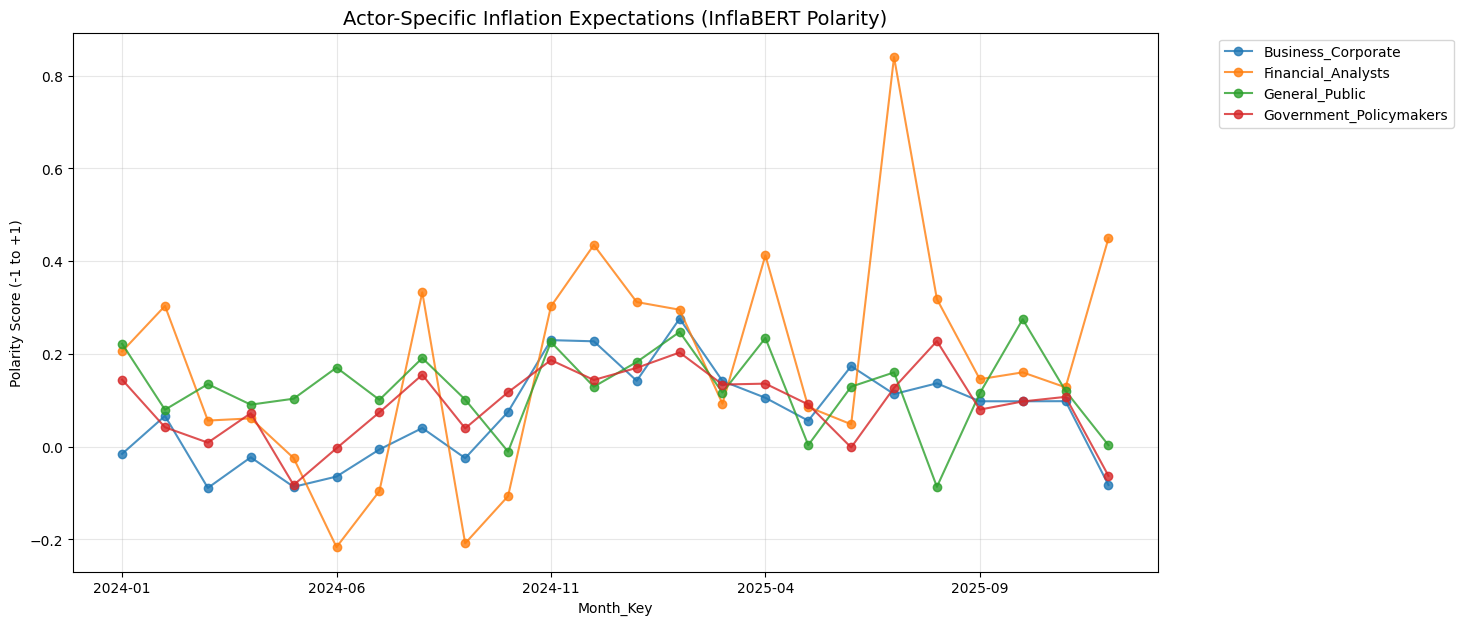

In [ ]:
actor_mapping = {
    'Business_Corporate': ['ECON_ENTREPRENEURSHIP', 'ECON_STOCKMARKET', 'WB_470_DEBT_MANAGEMENT'],
    'Government_Policymakers': ['GENERAL_GOVERNMENT', 'USPEC_POLICY1', 'EPU_POLICY_GOVERNMENT'],
    'Financial_Analysts': ['ECON_PRICECONTROL', 'WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT'],
    'Labor_Unions': ['LABOR_STRIKE', 'WB_2432_LABOR_MARKET_POLICY']
}

def categorize_actor(theme_str):
    if not isinstance(theme_str, str): return 'General_Public'
    for actor, keywords in actor_mapping.items():
        if any(kw in theme_str for kw in keywords):
            return actor
    return 'General_Public'

df_timeline = df[(df['Month_Key'] >= '2024-01') & (df['Month_Key'] <= '2025-12')].copy()
df_timeline['Actor_Category'] = df_timeline['V2Themes'].apply(categorize_actor)

actor_indices = df_timeline.groupby(['Month_Key', 'Actor_Category'])['InflaBERT_Polarity'].mean().unstack()

plt.figure(figsize=(14, 7))
actor_indices.plot(figsize=(14, 7), marker='o', alpha=0.8)
plt.title('Actor-Specific Inflation Expectations (InflaBERT Polarity)', fontsize=14)
plt.ylabel('Polarity Score (-1 to +1)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

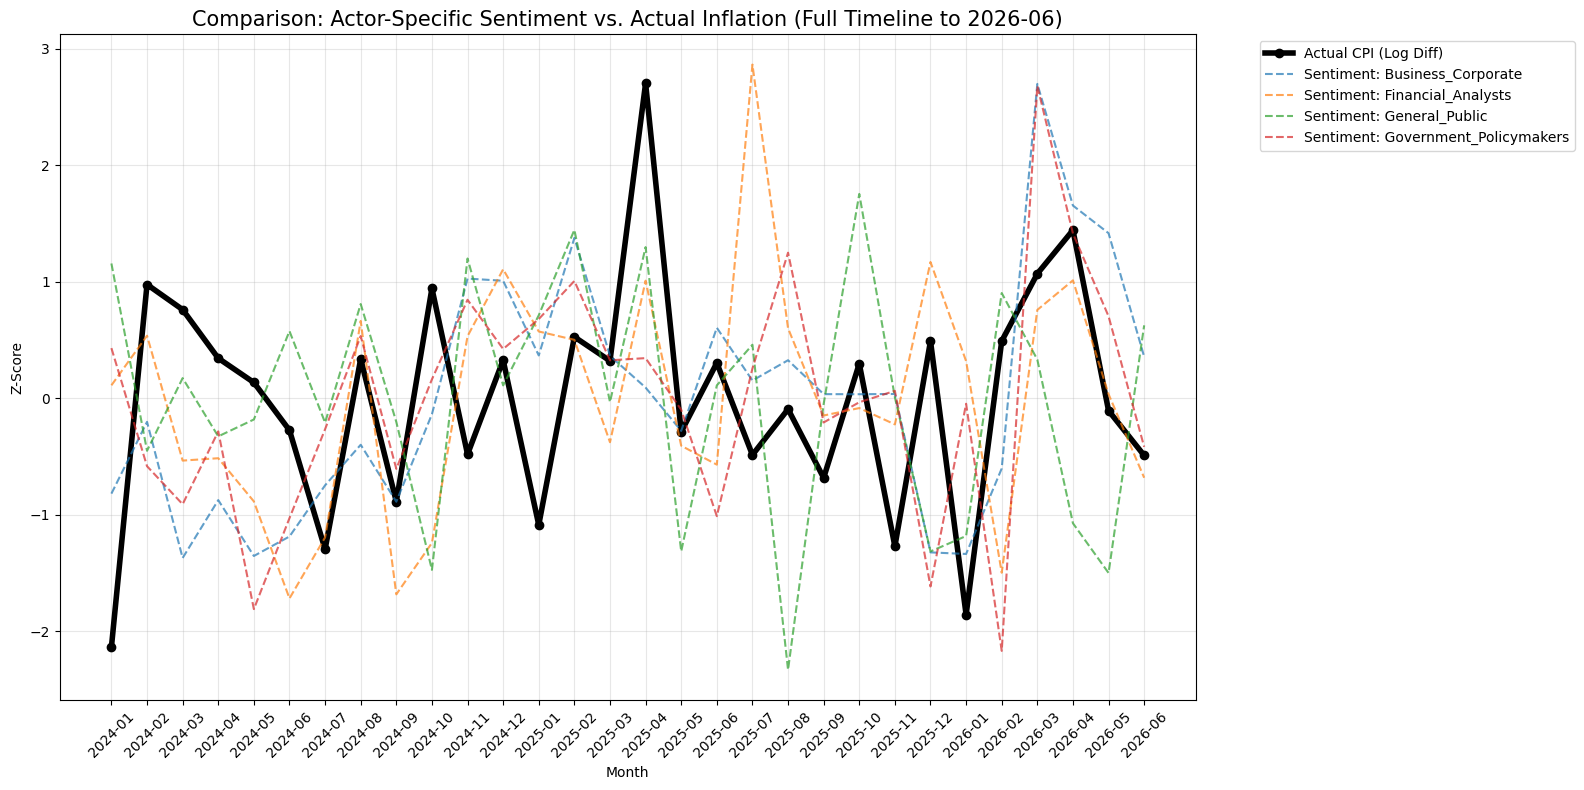

--- Correlation with Actual Inflation (Timeline: 2024-01 to 2026-06) ---
Business_Corporate         0.308775
Financial_Analysts         0.179793
Government_Policymakers    0.080409
General_Public             0.027800
Name: Inflation_Rate_LogDiff, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Expand the timeline filter to include the full available range until 2026-06
df_timeline_full = df[(df['Month_Key'] >= '2023-09') & (df['Month_Key'] <= '2026-06')].copy()
df_timeline_full['Actor_Category'] = df_timeline_full['V2Themes'].apply(categorize_actor)

# 2. Re-calculate Actor-Specific Sub-Indices using InflaBERT for the full range
actor_indices_full = df_timeline_full.groupby(['Month_Key', 'Actor_Category'])['InflaBERT_Polarity'].mean().unstack()

# 3. Align Actor Indices with ONS CPI Data
actor_cpi_df = pd.merge(online_cpi[['Month_Key', 'Inflation_Rate_LogDiff']], actor_indices_full, on='Month_Key', how='inner')

# 4. Standardize all series for visual comparison (Z-score)
def z_score(s):
    return (s - s.mean()) / s.std()

standardized_df = actor_cpi_df.copy()
for col in actor_cpi_df.columns:
    if col != 'Month_Key':
        standardized_df[col + '_Z'] = z_score(standardized_df[col])

# 5. Plotting the comparison through 2026-06
plt.figure(figsize=(16, 8))
plt.plot(standardized_df['Month_Key'], standardized_df['Inflation_Rate_LogDiff_Z'], label='Actual CPI (Log Diff)', color='black', linewidth=4, marker='o')

for actor in actor_indices_full.columns:
    plt.plot(standardized_df['Month_Key'], standardized_df[actor + '_Z'], label=f'Sentiment: {actor}', linestyle='--', alpha=0.7)

plt.title('Comparison: Actor-Specific Sentiment vs. Actual Inflation (Full Timeline to 2026-06)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Z-Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Correlation Analysis
print(f"--- Correlation with Actual Inflation (Timeline: {standardized_df['Month_Key'].min()} to {standardized_df['Month_Key'].max()}) ---")
correlations = actor_cpi_df.corr(numeric_only=True)['Inflation_Rate_LogDiff'].drop(['Inflation_Rate_LogDiff'])
print(correlations.sort_values(ascending=False))

Test all values